<a href="https://colab.research.google.com/github/riyakmanoj/Library-book-analysis/blob/main/Library%20book%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving book_details.csv to book_details.csv


In [ ]:

import pandas as pd

# Load the CSV file
df = pd.read_csv("book_details.csv")

# Display basic information
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

# Show first 5 rows
print("\nFirst 5 rows:")
print(df.head())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Basic statistics
print("\nDataset Statistics:")
print(df.describe(include='all'))

# Save cleaned dataset
df.to_csv("cleaned_book_details.csv", index=False)

print("\nCleaned dataset saved as 'cleaned_book_details.csv'")

Shape of dataset: (2000, 10)

Columns:
Index(['ISBN_10', 'ISBN_13', 'Title', 'Subtitle', 'Published Date', 'Authors',
       'Publisher', 'Language', 'Categories', 'Maturity Rating'],
      dtype='object')

First 5 rows:
      ISBN_10       ISBN_13  \
0  3663144380  9.783663e+12   
1  101710090X  9.781017e+12   
2  4893846345  9.784894e+12   
3  7532231747  9.787532e+12   
4  8472259315  9.788472e+12   

                                               Title   Subtitle  \
0  Entscheidungsspiele in Politik, Verwaltung und...        NaN   
1                        White Mountain Apache Texts        NaN   
2                                           ヨーロッパの変容  EC憲法体制の形成   
3                             名人传/青少版/[缩写本]/世界文学名著宝库        青少版   
4                                 Històries (vol. I)   Llibre I   

  Published Date                          Authors              Publisher  \
0     2013-09-03                    Astrid Wender        Springer-Verlag   
1     2022-10-27              Pliny E

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Load dataset
df = pd.read_csv("cleaned_book_details.csv")

# -------------------------
# STEP 1: SET TARGET COLUMN
# -------------------------
target = "Average Rating"   # 👈 CHANGE THIS if needed

# Drop missing values
df = df.dropna(subset=[target])

# Keep only numeric data (simple beginner-friendly approach)
numeric_df = df.select_dtypes(include=np.number)

# Ensure target exists after filtering
if target not in numeric_df.columns:
    raise ValueError("Target column not found in numeric columns!")

# Features and target
X = numeric_df.drop(columns=[target])
y = numeric_df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# -------------------------
# METRICS
# -------------------------
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE Score:", mae)

# -------------------------
# GRAPH
# -------------------------
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

# Save graph
graph_name = "prediction_graph.png"
plt.savefig(graph_name, dpi=300)
plt.show()

print("Graph saved as:", graph_name)

KeyError: ['Average Rating']

In [ ]:
print(df.columns)

Index(['ISBN_10', 'ISBN_13', 'Title', 'Subtitle', 'Published Date', 'Authors',
       'Publisher', 'Language', 'Categories', 'Maturity Rating'],
      dtype='object')


In [ ]:

# Print columns
print(df.columns)

# Try common target names
possible_targets = ["Average Rating", "average_rating", "ratings", "Rating"]

target = None
for col in possible_targets:
    if col in df.columns:
        target = col
        break

if target is None:
    raise ValueError("No valid target column found!")

print("Using target column:", target)

Index(['ISBN_10', 'ISBN_13', 'Title', 'Subtitle', 'Published Date', 'Authors',
       'Publisher', 'Language', 'Categories', 'Maturity Rating'],
      dtype='object')


ValueError: No valid target column found!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

df = pd.read_csv("cleaned_book_details.csv")

# Find correct target column automatically
possible_targets = ["Average Rating", "average_rating", "ratings", "Rating"]

target = None
for col in possible_targets:
    if col in df.columns:
        target = col
        break

if target is None:
    print(df.columns)
    raise ValueError("Target column not found in dataset!")

print("Using target column:", target)

# Drop missing values
df = df.dropna(subset=[target])

# Keep numeric columns only
numeric_df = df.select_dtypes(include=np.number)

X = numeric_df.drop(columns=[target])
y = numeric_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE Score:", mae)

# Graph
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.savefig("graph.png", dpi=300)
plt.show()

print("Graph saved as graph.png")

Index(['ISBN_10', 'ISBN_13', 'Title', 'Subtitle', 'Published Date', 'Authors',
       'Publisher', 'Language', 'Categories', 'Maturity Rating'],
      dtype='object')


ValueError: Target column not found in dataset!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("cleaned_book_details.csv")

# -----------------------------
# CREATE A FAKE NUMERIC TARGET
# -----------------------------
df["Target_Score"] = df["Title"].astype(str).apply(len)

target = "Target_Score"

# -----------------------------
# ENCODE CATEGORICAL DATA
# -----------------------------
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# -----------------------------
# MODEL
# -----------------------------
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# -----------------------------
# METRICS
# -----------------------------
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE Score:", mae)

# -----------------------------
# GRAPH
# -----------------------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.savefig("graph.png", dpi=300)
plt.show()

print("Graph saved as graph.png")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

R2 Score: 0.07367901006726318
MAE Score: 17.350915552563155


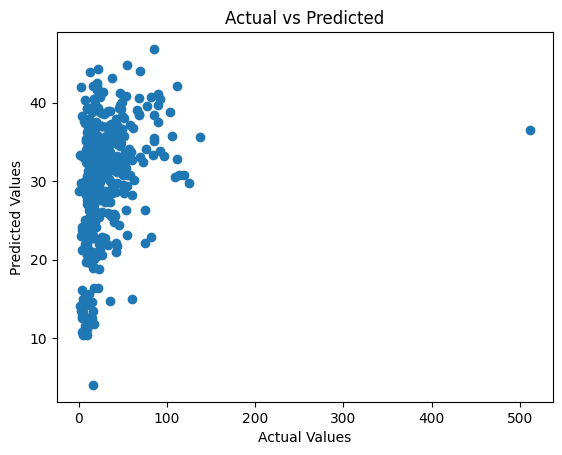

Graph saved as graph.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("cleaned_book_details.csv")

# -----------------------------
# Create target (since dataset has no numeric target)
# -----------------------------
df["Target_Score"] = df["Title"].astype(str).apply(len)

target = "Target_Score"

# -----------------------------
# Handle missing values FIRST
# -----------------------------
df = df.fillna("Unknown")   # fill text NaN

# -----------------------------
# Encode categorical columns
# -----------------------------
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# -----------------------------
# Final NaN check (VERY IMPORTANT)
# -----------------------------
df_encoded = df_encoded.dropna()

# -----------------------------
# Features & target
# -----------------------------
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# -----------------------------
# Metrics
# -----------------------------
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2 Score:", r2)
print("MAE Score:", mae)

# -----------------------------
# Graph
# -----------------------------
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.savefig("graph.png", dpi=300)
plt.show()

print("Graph saved as graph.png")